In [3]:

import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

np.set_printoptions(precision=2, suppress=True)
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


#1. Scalars, vectors, matrices & tensors

In [4]:
# 🔹 1A. THE FOUR CONTAINERS
scalar = np.array(5)
vector = np.array([2, 5, 1])
matrix = np.array([[1, 2], [3, 4]])
tensor = np.ones((3, 2, 2))

for name, arr in [('scalar', scalar), ('vector', vector),
                  ('matrix', matrix), ('tensor', tensor)]:
    print(f'{name:7s} ndim={arr.ndim}  shape={arr.shape}')

scalar  ndim=0  shape=()
vector  ndim=1  shape=(3,)
matrix  ndim=2  shape=(2, 2)
tensor  ndim=3  shape=(3, 2, 2)


In [5]:
# 🔹 1B. TENSOR OPERATIONS: add, transpose, reshape

A = np.arange(6).reshape(2, 3)   # shape (2, 3)
B = np.ones((2, 3), dtype=int)

print('A:\n', A)
print('A + B (element-wise add):\n', A + B)
print('A.T  (transpose -> shape', A.T.shape, '):\n', A.T)
print('A.reshape(3, 2):\n', A.reshape(3, 2))
print('A.flatten():', A.flatten())

A:
 [[0 1 2]
 [3 4 5]]
A + B (element-wise add):
 [[1 2 3]
 [4 5 6]]
A.T  (transpose -> shape (3, 2) ):
 [[0 3]
 [1 4]
 [2 5]]
A.reshape(3, 2):
 [[0 1]
 [2 3]
 [4 5]]
A.flatten(): [0 1 2 3 4 5]


In [6]:

T = np.arange(12).reshape(3, 4)

print('T:\n', T)

print("ndim:", T.ndim)
print("shape:", T.shape)


print("T + T:\n", T + T)

print("Transpose shape:", T.T.shape)
print("Reshaped (2, 6):\n", T.reshape(2, 6))

T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
ndim: 2
shape: (3, 4)
T + T:
 [[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]
Transpose shape: (4, 3)
Reshaped (2, 6):
 [[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]


#2. Dot & cross products, and norms

In [7]:
a = np.array([1, 2, 3])
b = np.array([4, 0, 1])

print('a . b  (dot)   :', np.dot(a, b))

print('a x b  (cross) :', np.cross(a, b))

a . b  (dot)   : 7
a x b  (cross) : [ 2 11 -8]


In [8]:
# 🔹 2B. NORMS (vector length) + COSINE SIMILARITY
print('L2 norm  ||a||_2 :', la.norm(a))
print('L1 norm  ||a||_1 :', la.norm(a, 1))
print('Linf norm        :', la.norm(a, np.inf))

def cosine(u, v):
    return np.dot(u, v) / (la.norm(u) * la.norm(v))

print('cosine(a, b)     :', round(cosine(a, b), 3))

L2 norm  ||a||_2 : 3.7416573867739413
L1 norm  ||a||_1 : 6.0
Linf norm        : 3.0
cosine(a, b)     : 0.454


In [9]:
pairs = [
    (np.array([2, 1, 3]), np.array([4, 2, 6])),
    (np.array([1, 3, 2]), np.array([2, 1, 4])),
    (np.array([5, 0, 2]), np.array([0, 3, 1])),
]

for i, (u, v) in enumerate(pairs, start=1):

    l1 = np.linalg.norm(u, ord=1)
    l2 = np.linalg.norm(u, ord=2)


    cosine = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

    print(f"Pair {i}:")
    print("  L1 norm:", l1)
    print("  L2 norm:", l2)
    print("  Cosine similarity:", cosine)

print("Most similar pair = Pair 1")

Pair 1:
  L1 norm: 6.0
  L2 norm: 3.7416573867739413
  Cosine similarity: 1.0
Pair 2:
  L1 norm: 6.0
  L2 norm: 3.7416573867739413
  Cosine similarity: 0.7581753965757457
Pair 3:
  L1 norm: 7.0
  L2 norm: 5.385164807134504
  Cosine similarity: 0.11744404390294069
Most similar pair = Pair 1


#3. Matrix operations & special matrices

In [11]:
A = np.array([[3., 2.],
              [1., 4.]])

B = np.array([[2., 1.],
              [5., 3.]])

print('A @ B (matrix multiply):\n', A @ B)
print('A.T   (transpose):\n', A.T)
print('inverse(A):\n', la.inv(A))
print('trace(A) = sum of diagonal:', np.trace(A))

A @ B (matrix multiply):
 [[16.  9.]
 [22. 13.]]
A.T   (transpose):
 [[3. 1.]
 [2. 4.]]
inverse(A):
 [[ 0.4 -0.2]
 [-0.1  0.3]]
trace(A) = sum of diagonal: 7.0


In [13]:
# 🔹 3B. SPECIAL MATRICES: identity, symmetric, orthogonal

A = np.array([[4., 1.],
              [1., 2.]])
I = np.eye(2)

print('Identity I:\n', I)
print('A @ inv(A) == I ?', np.allclose(A @ la.inv(A), I))

print('A symmetric?', np.allclose(A, A.T))

theta = np.radians(45)
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

print('Q:\n', Q)
print('Q orthogonal?', np.allclose(Q.T @ Q, I))

Identity I:
 [[1. 0.]
 [0. 1.]]
A @ inv(A) == I ? True
A symmetric? True
Q:
 [[ 0.71 -0.71]
 [ 0.71  0.71]]
Q orthogonal? True


In [14]:
M = np.array([[4., 2.],
              [2., 3.]])

P = np.array([[0., -1.],
              [1.,  0.]])

I = np.eye(2)

print("Inverse of M:\n", la.inv(M))
print("Trace of M:", np.trace(M))

print("M @ inv(M) == I ?", np.allclose(M @ la.inv(M), I))

print("M symmetric?", np.allclose(M, M.T))
print("P orthogonal?", np.allclose(P.T @ P, I))

Inverse of M:
 [[ 0.38 -0.25]
 [-0.25  0.5 ]]
Trace of M: 7.0
M @ inv(M) == I ? True
M symmetric? True
P orthogonal? True


#4. Transformations: rotation & scaling

In [16]:
rectangle = np.array([[0, 2, 2, 0],
                      [0, 0, 1, 1]], dtype=float)

S = np.array([[2.0, 0.0],
              [0.0, 1.5]])

t = np.radians(45)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])

scaled  = S @ rectangle
rotated = R @ rectangle

print('Scaled corners:\n', scaled)
print('Rotated corners:\n', rotated)

Scaled corners:
 [[0.  4.  4.  0. ]
 [0.  0.  1.5 1.5]]
Rotated corners:
 [[ 0.    1.41  0.71 -0.71]
 [ 0.    1.41  2.12  0.71]]


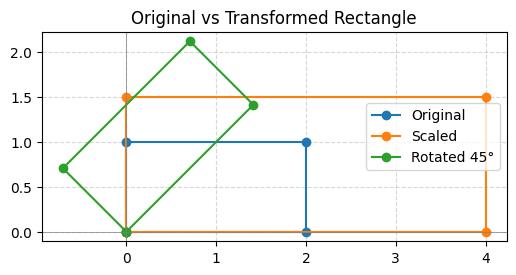

In [19]:
def close_loop(pts):

    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(*close_loop(rectangle),
        marker='o', label='Original')

ax.plot(*close_loop(scaled),
        marker='o', label='Scaled')

ax.plot(*close_loop(rotated),
        marker='o', label='Rotated 45°')

ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)

ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
ax.set_title('Original vs Transformed Rectangle')

plt.show()

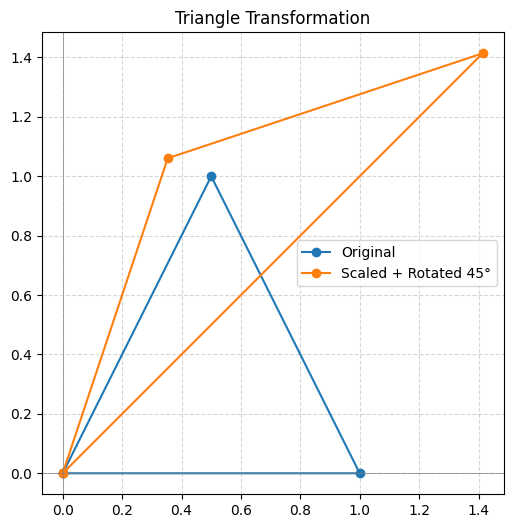

In [20]:
tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])

S = np.array([[2.0, 0.0],
              [0.0, 0.5]])


t = np.radians(45)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])

scaled = S @ tri
transformed = R @ scaled

def close_loop(pts):
    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(*close_loop(tri), marker='o', label='Original')
ax.plot(*close_loop(transformed), marker='o',
        label='Scaled + Rotated 45°')

ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)

ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
ax.set_title('Triangle Transformation')

plt.show()

#5. Eigenvalues & eigenvectors

For a matrix `A`, an **eigenvector** `v` is a direction that `A` only stretches (never rotates), and the **eigenvalue** `lambda` is how much it stretches it:  **A v = lambda v**.

In [21]:
A = np.array([[4., 1.],
              [2., 3.]])

vals, vecs = la.eig(A)

print('Eigenvalues  (lambda):', vals)
print('Eigenvectors (columns):\n', vecs)

Eigenvalues  (lambda): [5. 2.]
Eigenvectors (columns):
 [[ 0.71 -0.45]
 [ 0.71  0.89]]


In [22]:
A = np.array([[5., 2.],
              [1., 4.]])

vals, vecs = la.eig(A)

for i in range(len(vals)):
    v = vecs[:, i]
    lhs = A @ v
    rhs = vals[i] * v
    print(f'lambda={vals[i]:.1f}  A v == lambda v ?',
          np.allclose(lhs, rhs))

lambda=6.0  A v == lambda v ? True
lambda=3.0  A v == lambda v ? True


In [23]:
C = np.array([[4., 1.],
              [2., 3.]])

vals, vecs = la.eig(C)

print("Eigenvalues:", vals)

v = vecs[:, 0]

lhs = C @ v
rhs = vals[0] * v

print("First eigenvector:", v)
print("C @ v:", lhs)
print("lambda @ v:", rhs)
print("A v == lambda v ?", np.allclose(lhs, rhs))

Eigenvalues: [5. 2.]
First eigenvector: [0.71 0.71]
C @ v: [3.54 3.54]
lambda @ v: [3.54 3.54]
A v == lambda v ? True


#6. Rank, solving systems & cosine similarity

In [24]:
A = np.array([[ 1.,  2.,  1.],
              [ 2., -1.,  3.],
              [ 3.,  1., -1.]])

b = np.array([9., 13., 4.])

x = la.solve(A, b)

print('Solution x:', x)
print('Rank of A :', la.matrix_rank(A))
print('Full rank -> a unique solution exists')

Solution x: [1.96 1.72 3.6 ]
Rank of A : 3
Full rank -> a unique solution exists


In [27]:
D = np.array([[1., 4., 7.],
              [2., 5., 8.],
              [3., 6., 9.]])
print('Rank of D:', la.matrix_rank(D), '-> < 3, so rows are dependent')

Rank of D: 2 -> < 3, so rows are dependent


In [31]:
import numpy as np

car    = np.array([0.9, 0.7, 0.2, 0.1])
truck  = np.array([0.8, 0.6, 0.3, 0.2])
banana = np.array([0.1, 0.2, 0.8, 0.9])

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print('cosine(car, truck):', round(cosine_similarity(car, truck), 3))
print('cosine(car, banana):', round(cosine_similarity(car, banana), 3))

cosine(car, truck): 0.988
cosine(car, banana): 0.337


In [33]:
A2 = np.array([[3., 2.],
               [1., 4.]])
b2 = np.array([7., 9.])

cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])

x = la.solve(A2, b2)
print("Solution x:", x)

rank = la.matrix_rank(A2)
print("Rank of A2:", rank)

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

cat_dog = cosine_similarity(cat, dog)
cat_car = cosine_similarity(cat, car)

print("cosine(cat, dog):", round(cat_dog, 3))
print("cosine(cat, car):", round(cat_car, 3))

if cat_dog > cat_car:
    print("More similar: cat and dog")
else:
    print("More similar: cat and car")

Solution x: [1. 2.]
Rank of A2: 2
cosine(cat, dog): 0.995
cosine(cat, car): 0.293
More similar: cat and dog
